In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./data/train.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21096\599420964.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/train.csv")


#
# 11. Suppression des lignes dupliquees

In [3]:
df.duplicated().sum()

np.int64(0)

### Il y'a aucun doublon dans ce dataset

#
# 12. Suppression des valeurs parasites dans les variables numériques

In [4]:
cat_cols = ["SSN", "Occupation", "Credit_Mix", "Payment_Behaviour", "Credit_Score"]

for col in cat_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"[^a-zA-Z0-9 _-]", "", regex=True)  # garde texte + chiffres utiles
        .str.strip()
        .replace("", pd.NA)
    )
df = df.replace(["!@#", "___", "NaN", "nan", ""], pd.NA)
# 1. nettoyage de base
df["Occupation"] = (
    df["Occupation"]
    .str.lower()
    .str.strip()
)

# 2. fonction mode par groupe
mode_by_customer = (
    df.groupby("Customer_ID")["Occupation"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [5]:
cols = ["Age","Monthly_Inhand_Salary","Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate", "Delay_from_due_date",
            "Annual_Income", "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance", "Num_of_Loan",
            "Credit_Utilization_Ratio", "Total_EMI_per_month","Num_of_Delayed_Payment"]

for col in cols :
     df[col] = pd.to_numeric(df[col].astype(str).str.replace(r"[^\d.-]", "", regex=True),
        errors="coerce") # supprime les caratères abérrants des valeurs numériques et convertit en varaible de type numérique (int ou float)

In [6]:
cols = df.select_dtypes(include="object").columns.difference(["ID", "Customer_ID", "SSN"])

df[cols] = df[cols].astype("category") # Coversion de toutes les variables de type Objecct (sauf ID, Customer_ID et SSN) en type Category

In [7]:
df.dtypes # Vérification

ID                            object
Customer_ID                   object
Month                       category
Name                        category
Age                            int64
SSN                           object
Occupation                  category
Annual_Income                float64
Monthly_Inhand_Salary        float64
Num_Bank_Accounts              int64
Num_Credit_Card                int64
Interest_Rate                  int64
Num_of_Loan                    int64
Type_of_Loan                category
Delay_from_due_date            int64
Num_of_Delayed_Payment       float64
Changed_Credit_Limit        category
Num_Credit_Inquiries         float64
Credit_Mix                  category
Outstanding_Debt             float64
Credit_Utilization_Ratio     float64
Credit_History_Age          category
Payment_of_Min_Amount       category
Total_EMI_per_month          float64
Amount_invested_monthly      float64
Payment_Behaviour           category
Monthly_Balance              float64
C

#
# 13. Correction des valeurs aberrantes

In [8]:
col = ["Age"]
df[col] = df[col].where((df[col] >= 18) & (df[col] <= 100), np.nan)# Conversion des valeurs en dehors de l'intervalle [18, 100] en valeur manquante
med_age = df.groupby("Customer_ID")["Age"].transform("median")

mask = abs(df["Age"] - med_age) > 1

df.loc[mask, "Age"] = med_age[mask]

In [9]:
col = ["Num_Bank_Accounts"]
df[col] = df[col].where((df[col] >= 0), np.nan) # Conversion des valeurs négatives en valeur manquante

In [10]:
listeS = ["Annual_Income","Num_Bank_Accounts","Num_Credit_Card","Num_of_Loan",'Delay_from_due_date', 'Num_Credit_Inquiries',
         'Total_EMI_per_month','Num_of_Delayed_Payment']
for var in listeS:

    med = df.groupby("Customer_ID")[var].transform("median")

    q1 = df.groupby("Customer_ID")[var].transform(lambda x: x.quantile(0.25))
    q3 = df.groupby("Customer_ID")[var].transform(lambda x: x.quantile(0.75))

    iqr = q3 - q1

    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr

    mask = (df[var] < borne_inf) | (df[var] > borne_sup)

    df.loc[mask, var] = np.nan

    df[var] = df[var].fillna(med)

## Imputation

In [11]:
df_num = df.select_dtypes(include="number")

In [12]:
listeN = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_Credit_Inquiries', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Num_of_Delayed_Payment']
for var in listeN:
    mediane_client = df.groupby("Customer_ID")[var].transform("median")

    df[var] = df[var].fillna(mediane_client)
    df[var] = df[var].fillna(df[var].median()) # On impute par la médiane de chaque variable propre à chaque client et par la médiane de la colonne en cas
                                                # d'information manquante

In [13]:
df.dtypes

ID                            object
Customer_ID                   object
Month                       category
Name                        category
Age                          float64
SSN                           object
Occupation                  category
Annual_Income                float64
Monthly_Inhand_Salary        float64
Num_Bank_Accounts            float64
Num_Credit_Card              float64
Interest_Rate                  int64
Num_of_Loan                  float64
Type_of_Loan                category
Delay_from_due_date          float64
Num_of_Delayed_Payment       float64
Changed_Credit_Limit        category
Num_Credit_Inquiries         float64
Credit_Mix                  category
Outstanding_Debt             float64
Credit_Utilization_Ratio     float64
Credit_History_Age          category
Payment_of_Min_Amount       category
Total_EMI_per_month          float64
Amount_invested_monthly      float64
Payment_Behaviour           category
Monthly_Balance              float64
C

In [14]:
df_cat = df.select_dtypes(exclude="number")

In [15]:
df_cat.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Occupation',
       'Type_of_Loan', 'Changed_Credit_Limit', 'Credit_Mix',
       'Credit_History_Age', 'Payment_of_Min_Amount', 'Payment_Behaviour',
       'Credit_Score'],
      dtype='object')

In [16]:
listeC = ['Month', 'Name', 'SSN', 'Occupation',
       'Type_of_Loan', 'Changed_Credit_Limit',
       'Credit_Mix', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score']
for var in listeC:
    mode_par_client = (
        df.groupby("Customer_ID")[var]
          .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )

    df[var] = df[var].fillna(mode_par_client) # On remplace par le mode de chaque variable propre à chaque client

In [17]:
df.isna().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                            0
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary           0
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment          0
Changed_Credit_Limit            0
Num_Credit_Inquiries            0
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age              0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly         0
Payment_Behaviour               0
Monthly_Balance                 0
Credit_Score                    0
dtype: int64

In [18]:
df["Type_of_Loan"].value_counts()

Type_of_Loan
Not Specified                                                                                                        1408
Credit-Builder Loan                                                                                                  1280
Personal Loan                                                                                                        1272
Debt Consolidation Loan                                                                                              1264
Student Loan                                                                                                         1240
                                                                                                                     ... 
Home Equity Loan, Debt Consolidation Loan, Credit-Builder Loan, and Home Equity Loan                                    8
Home Equity Loan, Debt Consolidation Loan, Credit-Builder Loan, and Credit-Builder Loan                                 8
Home Equity

In [19]:
df["Type_of_Loan"].describe()

count             88592
unique             6260
top       Not Specified
freq               1408
Name: Type_of_Loan, dtype: object

In [20]:
df["Type_of_Loan"] = df["Type_of_Loan"].fillna(df["Type_of_Loan"].mode()[0])

In [21]:
df.isna().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [22]:
df["Credit_History_Age"]

0         22 Years and 1 Months
1         22 Years and 1 Months
2         22 Years and 3 Months
3         22 Years and 4 Months
4         22 Years and 5 Months
                  ...          
99995     31 Years and 6 Months
99996     31 Years and 7 Months
99997     31 Years and 8 Months
99998     31 Years and 9 Months
99999    31 Years and 10 Months
Name: Credit_History_Age, Length: 100000, dtype: category
Categories (404, object): ['0 Years and 1 Months', '0 Years and 10 Months', '0 Years and 11 Months', '0 Years and 2 Months', ..., '9 Years and 6 Months', '9 Years and 7 Months', '9 Years and 8 Months', '9 Years and 9 Months']

In [23]:
df["Credit_History_Age"] = (
    df["Credit_History_Age"]
    .astype(str)
    .str.extract(r"(\d+)\s*Year?")[0].astype(float)*12
    +
    df["Credit_History_Age"]
    .astype(str)
    .str.extract(r"(\d+)\s*Month")[0].astype(float).fillna(0)
)

In [24]:
df["Credit_History_Age"].describe()

count    100000.000000
mean        221.111580
std          99.668748
min           1.000000
25%         144.000000
50%         219.000000
75%         302.000000
max         404.000000
Name: Credit_History_Age, dtype: float64

In [25]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [26]:
cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_Credit_Inquiries', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance',
    'Num_of_Delayed_Payment'
]

mask = pd.Series(False, index=df.index)

for col in cols:

    Q1 = df.groupby("Customer_ID")[col].transform(lambda x: x.quantile(0.25))
    Q3 = df.groupby("Customer_ID")[col].transform(lambda x: x.quantile(0.75))

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask |= (df[col] < lower) | (df[col] > upper)

df_outliers = df[mask]

print(f"Nombre de lignes contenant au moins un outlier : {len(df_outliers)}")
df_outliers.head()

Nombre de lignes contenant au moins un outlier : 26341


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28.0,004-07-5839,_______,34847.84,3037.986667,2.0,...,Good,605.03,24.464031,319.0,No,18.816215,104.291825,Low_spent_Small_value_payments,470.690627,Standard
15,0x1615,CUS_0x21b1,August,Rick Rothackerj,28.0,004-07-5839,teacher,34847.84,3037.986667,2.0,...,Good,605.03,32.933856,326.0,No,18.816215,218.904344,Low_spent_Small_value_payments,356.078109,Good
18,0x161c,CUS_0x2dbc,March,Langep,34.0,486-85-3974,_______,143162.64,12187.220000,1.0,...,Good,1303.01,26.519815,215.0,No,246.992319,10000.000000,High_spent_Small_value_payments,715.741367,Good
19,0x161d,CUS_0x2dbc,April,Langep,34.0,486-85-3974,engineer,143162.64,12187.220000,1.0,...,_,1303.01,39.501648,214.0,No,246.992319,825.216270,Low_spent_Medium_value_payments,426.513411,Good
20,0x161e,CUS_0x2dbc,May,Langep,34.0,486-85-3974,_______,143162.64,12187.220000,1.0,...,Good,1303.01,31.376150,217.0,No,246.992319,430.947528,Low_spent_Large_value_payments,810.782153,Good


In [34]:
df_outliers.shape

(26341, 28)

## Suppression des colonnes 

In [27]:
df = df.drop(columns=["Customer_ID", 'ID', 'Month', 'Type_of_Loan'])

In [28]:
df.columns

Index(['Name', 'Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [29]:
df.shape

(100000, 24)

In [30]:
df.to_csv("data/train_clean.csv", index=False) 

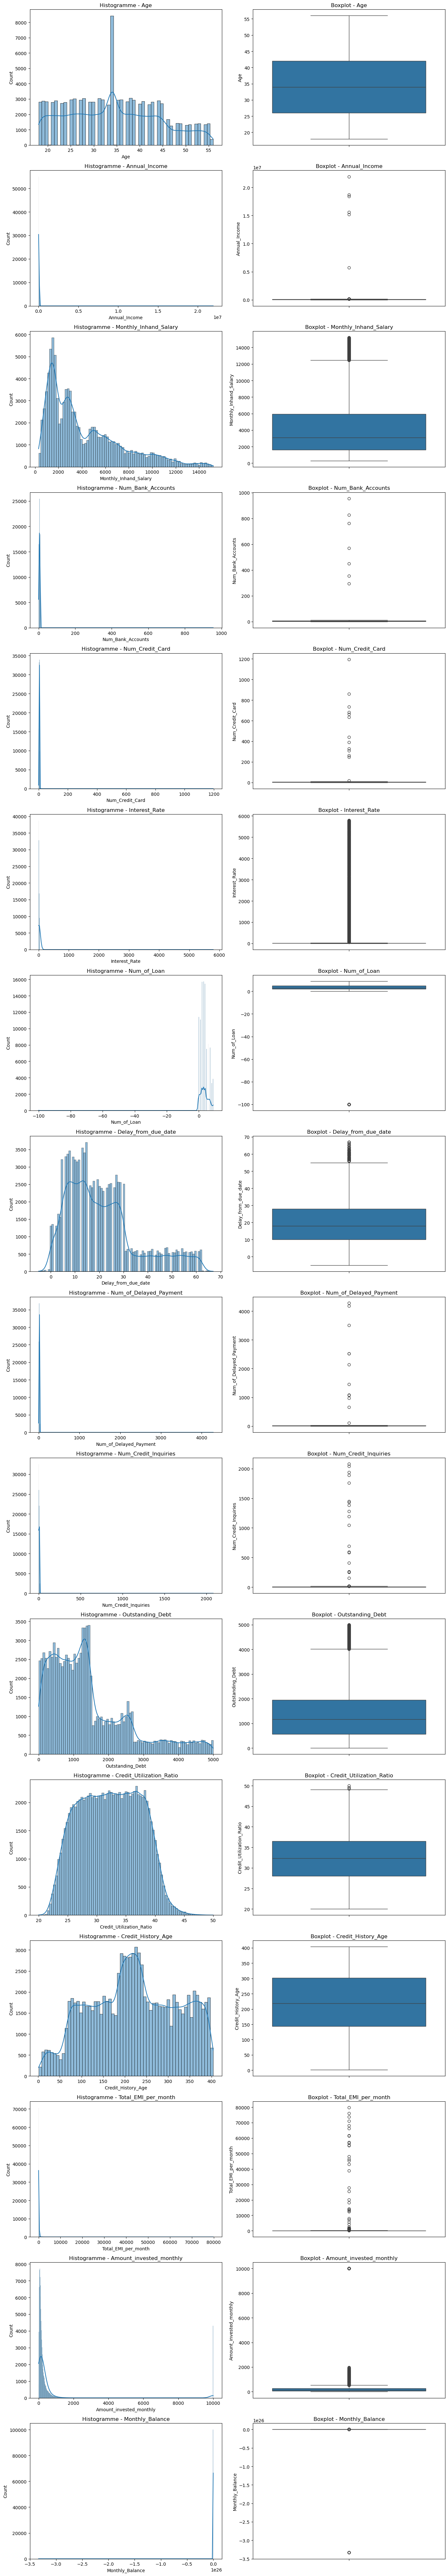

In [31]:
# Colonnes numériques
cols = df.select_dtypes(include="number").columns

# Nombre de variables
n = len(cols)

# Création des subplots
fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(14, 5*n)
)

# Si une seule variable
if n == 1:
    axes = [axes]

# Boucle
for i, col in enumerate(cols):
    
    # Histogramme
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        edgecolor="black",
        ax=axes[i,0]
    )
    
    axes[i,0].set_title(f"Histogramme - {col}")
    
    # Boxplot
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i,1]
    )
    
    axes[i,1].set_title(f"Boxplot - {col}")

# Ajustement
plt.tight_layout()

plt.show()

In [32]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,34.334430,5.145607e+04,4198.490149,5.410915,5.600860,72.466040,3.418990,21.06828,13.560240,5.996180,1426.220376,32.285173,221.111580,119.193120,617.257610,-3.000000e+22
std,9.858117,1.345878e+05,3187.491752,5.947716,7.104814,466.422621,4.213839,14.78723,27.289878,17.885484,1155.129026,5.116875,99.668748,815.211289,1999.677146,3.162151e+24
min,18.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,-100.000000,-5.00000,-3.000000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,-3.333333e+26
25%,26.000000,1.934297e+04,1626.761667,3.000000,4.000000,8.000000,2.000000,10.00000,9.000000,3.000000,566.072500,28.052567,144.000000,29.268886,75.356284,2.703078e+02
50%,34.000000,3.700258e+04,3095.978333,5.000000,5.000000,13.000000,3.000000,18.00000,14.000000,5.000000,1166.155000,32.305784,219.000000,66.506180,136.173912,3.372525e+02
75%,42.000000,7.168968e+04,5961.637500,7.000000,7.000000,20.000000,5.000000,28.00000,18.000000,8.000000,1945.962500,36.496663,302.000000,147.392573,263.231662,4.719186e+02
max,56.000000,2.193619e+07,15204.633333,955.000000,1196.000000,5797.000000,9.000000,67.00000,4281.000000,2081.000000,4998.070000,50.000000,404.000000,79756.000000,10000.000000,1.602041e+03
